In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [2]:
df = pd.read_csv("../Data/food_center.csv")

In [3]:
df.head()

,Unnamed: 0,id,week,center_id,meal_id,checkout_price,base_price,emailer_for_promotion,homepage_featured,num_orders,city_code,region_code,center_type,op_area,category,cuisine
0,0,1379560,1,55,1885,136.83,152.29,0,0,177,647,56,TYPE_C,2.0,Beverages,Thai
1,1,1018704,2,55,1885,135.83,152.29,0,0,323,647,56,TYPE_C,2.0,Beverages,Thai
2,2,1196273,3,55,1885,132.92,133.92,0,0,96,647,56,TYPE_C,2.0,Beverages,Thai
3,3,1116527,4,55,1885,135.86,134.86,0,0,163,647,56,TYPE_C,2.0,Beverages,Thai
4,4,1343872,5,55,1885,146.50,147.50,0,0,215,647,56,TYPE_C,2.0,Beverages,Thai


In [4]:
df.shape

(456548, 16)

In [5]:
df.isnull().any()

Unnamed: 0               False
id                       False
week                     False
center_id                False
meal_id                  False
checkout_price           False
base_price               False
emailer_for_promotion    False
homepage_featured        False
num_orders               False
city_code                False
region_code              False
center_type              False
op_area                  False
category                 False
cuisine                  False
dtype: bool

In [6]:
#1- What is the highest ordered category in term of check out price?

Highest_Checkout = df.groupby ("category").sum()[["checkout_price"]].sort_values(by="checkout_price", ascending=False)
Highest_Checkout


,checkout_price
category,
Beverages,27274335.97
Pizza,19352729.40
Seafood,16434870.57
Desert,12819059.27
Pasta,10957496.95
Rice Bowl,10608117.08
Sandwich,9654023.75
Biryani,9284651.88
Starters,8331741.86


In [7]:
Highest_Checkout.head()

,checkout_price
category,
Beverages,27274335.97
Pizza,19352729.40
Seafood,16434870.57
Desert,12819059.27
Pasta,10957496.95


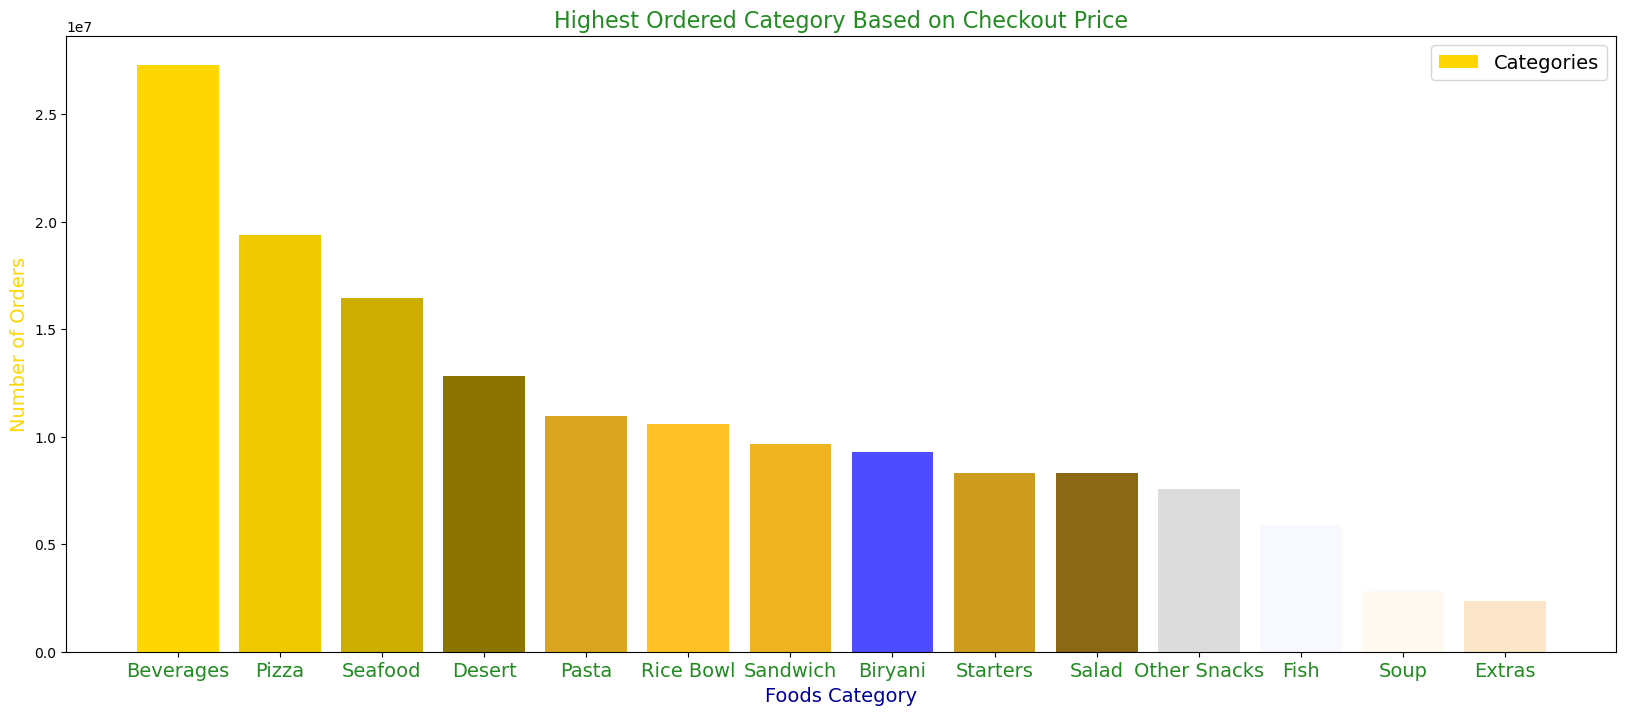

In [8]:
plt.figure(figsize = (20,8))
HOC = Highest_Checkout.index

ax = plt.axes()
X = range(len(Highest_Checkout))
plt.bar(X,Highest_Checkout["checkout_price"],width=0.8, color=['#FFD700',"#EEC900","#CDAD00","#8B7500", "#DAA520",
                                                                 "#FFC125", "#EEB422", "#4d4dff","#CD9B1D", "#8B6914",
                                                                 "#DCDCDC","#F8F8FF", "#FFFAF0", "#FCE6C9"], label="Categories")
plt.title("Highest Ordered Category Based on Checkout Price",fontsize=16, color="#228B22")
plt.xlabel("Foods Category", color="#000099", fontsize=14)
plt.ylabel("Number of Orders",color="#FFD700", fontsize=14)
plt.xticks(X,HOC, rotation =360 , fontsize=14, color="#228B22")

plt.title("Highest Ordered Category Based on Checkout Price",fontsize=16, color="#228B22")
plt.legend(fontsize=14)
plt.savefig('chart1.png', bbox_inches='tight', dpi=150)
plt.show()
#Beverages are the most ordered category based on the check out price.
#In other words, considering check out prices, people have ordered beverages the most.

In [9]:
df.head()

,Unnamed: 0,id,week,center_id,meal_id,checkout_price,base_price,emailer_for_promotion,homepage_featured,num_orders,city_code,region_code,center_type,op_area,category,cuisine
0,0,1379560,1,55,1885,136.83,152.29,0,0,177,647,56,TYPE_C,2.0,Beverages,Thai
1,1,1018704,2,55,1885,135.83,152.29,0,0,323,647,56,TYPE_C,2.0,Beverages,Thai
2,2,1196273,3,55,1885,132.92,133.92,0,0,96,647,56,TYPE_C,2.0,Beverages,Thai
3,3,1116527,4,55,1885,135.86,134.86,0,0,163,647,56,TYPE_C,2.0,Beverages,Thai
4,4,1343872,5,55,1885,146.50,147.50,0,0,215,647,56,TYPE_C,2.0,Beverages,Thai


In [10]:
#2- What is the lists of Visitors in each Cuisine Based on Center Type?


Cuisine_Visitors= df.groupby(["cuisine","center_type"])[["num_orders"]].sum().unstack('center_type')
Cuisine_Visitors

num_orders                  
center_type     TYPE_A   TYPE_B   TYPE_C
cuisine                                 
Continental    9874117  3559456  3480866
Indian        14512558  6944518  4335468
Italian       24778761  9939385  9454686
Thai          19813081  9552714  3311875

<Figure size 2000x800 with 0 Axes>

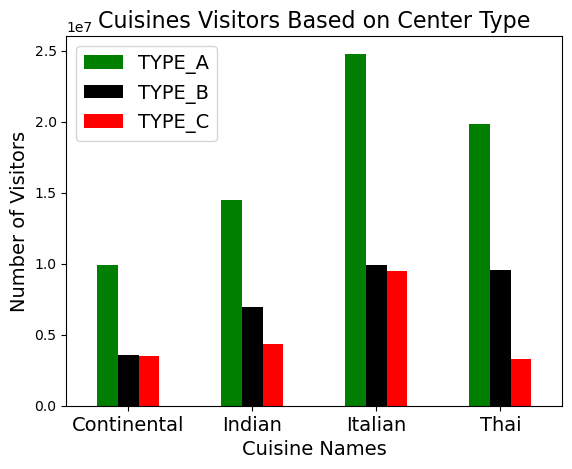

In [11]:
plt.figure(figsize =(20,8))
Cuisine_Visitors.plot(kind="bar", color=['green',"k","red"])
plt.title("Cuisines Visitors Based on Center Type",fontsize=16)


plt.xlabel("Cuisine Names",fontsize=14)
plt.ylabel("Number of Visitors",fontsize=14)
plt.xticks(rotation=360, fontsize=14)

plt.legend(Cuisine_Visitors.num_orders, loc="upper left", fontsize=14)
plt.savefig('chart2.png', bbox_inches='tight', dpi=150)
plt.show()
#Type A has been the most ordered cuisine within all other foods, 
#especially Type A of Italian food has the highest frequency.

In [12]:
#3- What is the highest ordered category in term of base price?

HighestC_Basedby= df.groupby(["category"])[["base_price"]].sum()
df2 = HighestC_Basedby.sort_values("base_price", ascending =False)
df2

,base_price
category,
Beverages,29012435.97
Pizza,21333091.93
Seafood,17903883.76
Desert,13667380.44
Pasta,11854292.37
Rice Bowl,11338233.48
Sandwich,10161531.28
Biryani,9502276.71
Salad,8584239.78


In [13]:
df2.head()

,base_price
category,
Beverages,29012435.97
Pizza,21333091.93
Seafood,17903883.76
Desert,13667380.44
Pasta,11854292.37


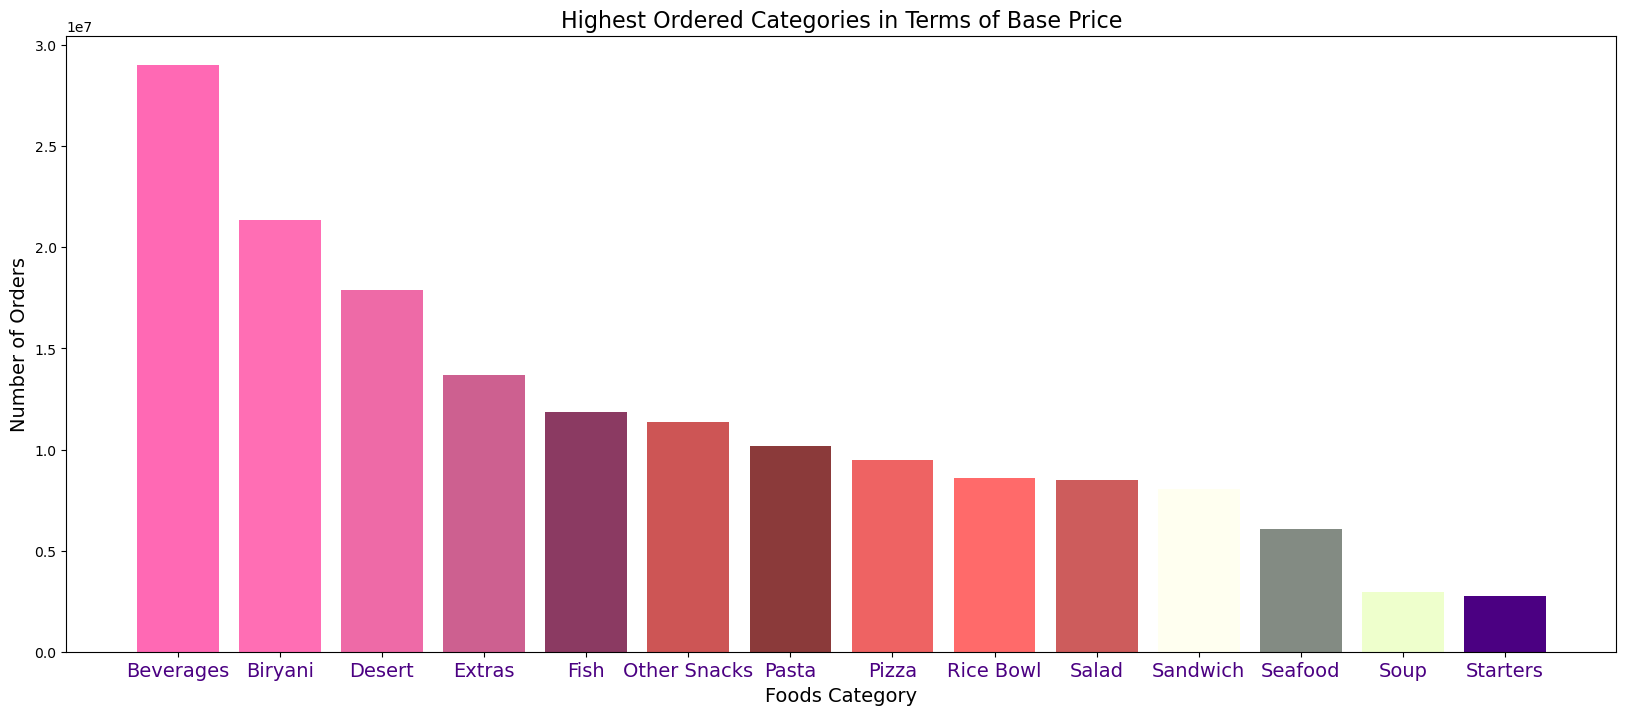

In [14]:
plt.figure(figsize = (20,8))
ax = plt.axes()
df3 = HighestC_Basedby.index
X = range(len(df2))

plt.bar(X,df2["base_price"],width=0.8, color=['#FF69B4',"#FF6EB4","#EE6AA7","#CD6090", "#8B3A62",
                                                                 "#CD5555", "#8B3A3A", "#EE6363","#FF6A6A", "#CD5C5C",
                                                               "#FFFFF0","#838B83", "#eeffcc", "#4B0082"])
plt.xticks(X,df3, rotation=360, fontsize=14, color="#4B0082")
plt.xlabel("Foods Category", fontsize=14 )
plt.ylabel("Number of Orders",fontsize=14)
plt.title("Highest Ordered Categories in Terms of Base Price",fontsize=16)
plt.savefig('chart3.png', bbox_inches='tight', dpi=150)
plt.show()
#The graph indicates that beverages has the highest number of orders
#based on base price.


In [15]:
#2-  What is the highest number of orders according to category?

NumOrders_Category= df.groupby(["category"])[["num_orders"]].max()
NumOrders_Category = NumOrders_Category.sort_values("num_orders",ascending=False)
NumOrders_Category

,num_orders
category,
Rice Bowl,24299
Sandwich,13150
Beverages,9303
Salad,8059
Other Snacks,3861
Pizza,2620
Extras,1620
Seafood,1620
Starters,1554


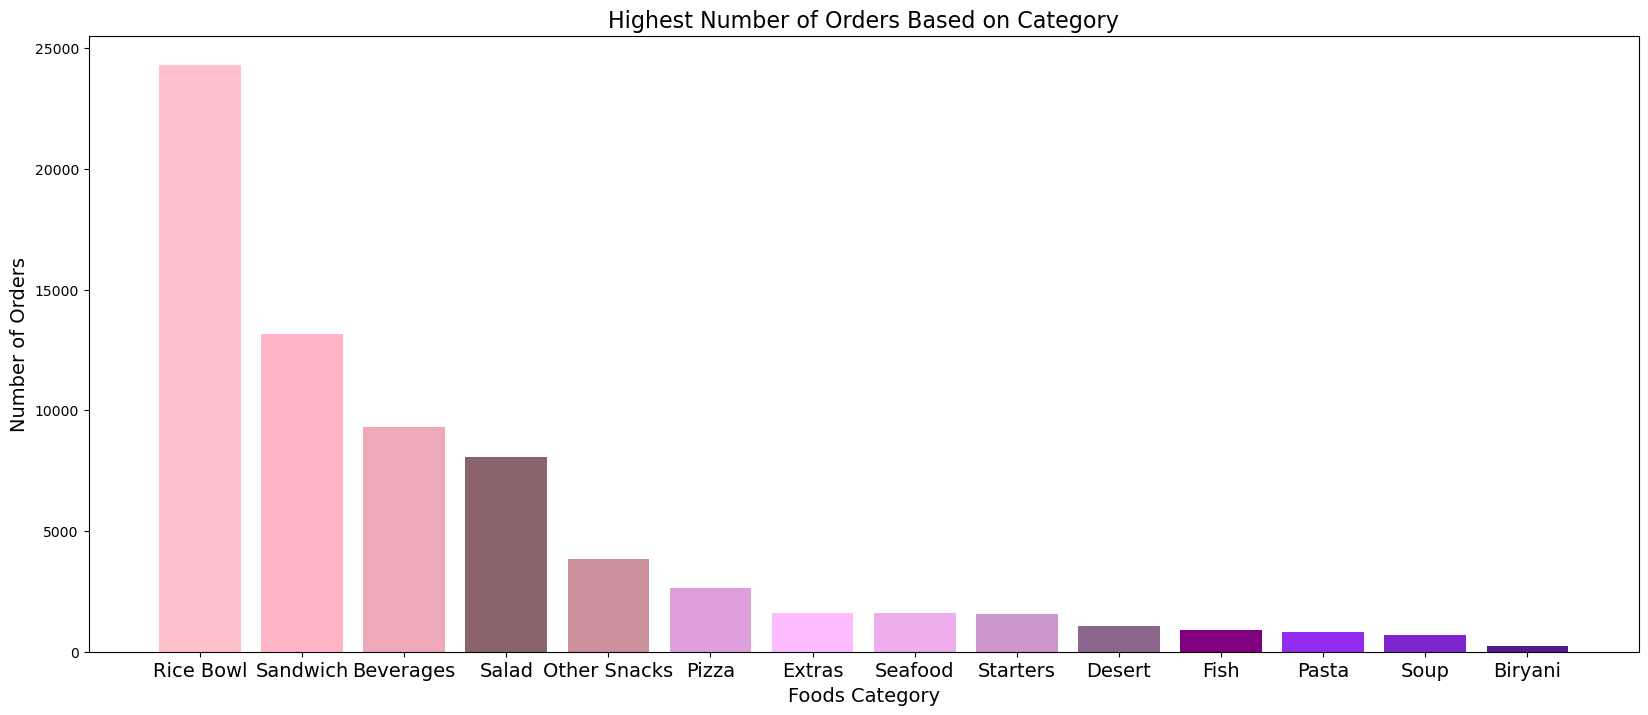

In [16]:
plt.figure(figsize = (20,8))

ax = plt.axes()
Nums = NumOrders_Category.index
X = range(len(NumOrders_Category))

plt.bar(X,NumOrders_Category["num_orders"],width=0.8, color=['#FFC0CB',"#FFB5C5","#EEA9B8","#8B636C", "#CD919E",
                                                                 "#DDA0DD", "#FFBBFF", "#EEAEEE","#CD96CD", "#8B668B",
                                                                 "#800080","#912CEE", "#7D26CD", "#551A8B"])
plt.xticks(X,Nums, rotation=0, fontsize=14)
plt.xlabel("Foods Category",  fontsize=14 )
plt.ylabel("Number of Orders", fontsize=14)
plt.title("Highest Number of Orders Based on Category",fontsize=16)
plt.savefig('chart4.png', bbox_inches='tight', dpi=150)
plt.show()
#The graph shows the Rice Bowl has the highest number of order based on category

In [17]:
#5- Which food has the highest number of order?
HighestCuisineOrder= df.groupby(["cuisine"])[["num_orders"]].sum()
HighestCuisineOrder = HighestCuisineOrder.sort_values("num_orders",ascending=False)
HighestCuisineOrder


,num_orders
cuisine,
Italian,44172832
Thai,32677670
Indian,25792544
Continental,16914439


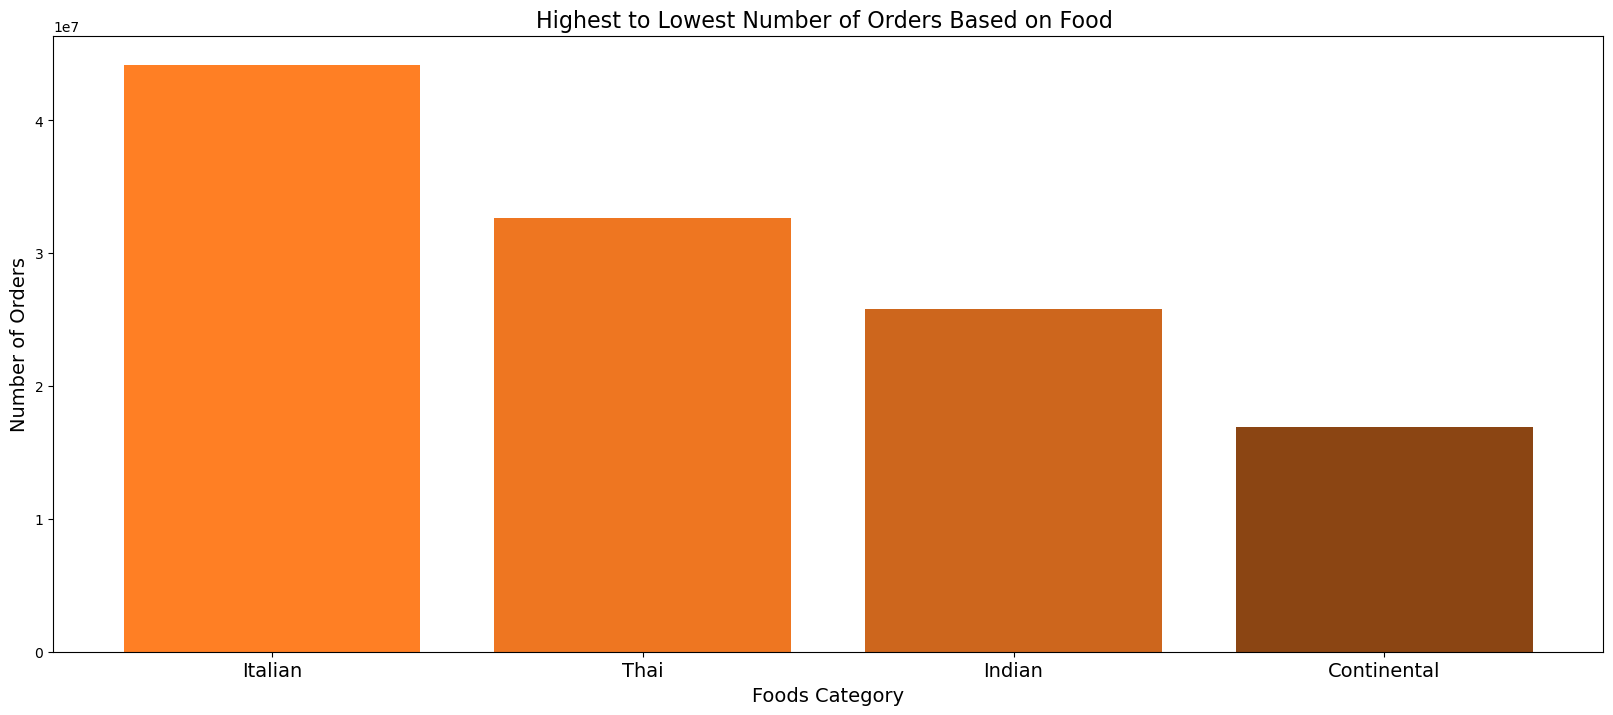

In [18]:
plt.figure(figsize = (20,8))

ax = plt.axes()
HCO = HighestCuisineOrder.index
X = range(len(HighestCuisineOrder))

plt.bar(X,HighestCuisineOrder["num_orders"],width=0.8, color=['#FF7F24',"#EE7621","#CD661D","#8B4513"])
plt.xticks(X,HCO, rotation=360, fontsize=14)
plt.xlabel("Foods Category",  fontsize=14)
plt.ylabel("Number of Orders", fontsize=14)
plt.title("Highest to Lowest Number of Orders Based on Food ",fontsize=16)
plt.savefig('chart5.png', bbox_inches='tight', dpi=150)
plt.show()

#The graph shows that Italian food has the highest number of order.
